### 1. Import + data

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/processed/model_input.csv")

df.head()

,race_id,year,event_date,time,latitude,longitude,tmin,tmax,tavg,prcp,wspd,rhum,hot_day_flag,very_hot_day_flag,rain_flag,windy_day_flag,humid_day_flag,temp_range,n_finishers,winner_time_sec,median_time_sec
0,im_lanzarote,2011,2011-05-21,2011-05-21,28.9236,-13.6654,20.4,27.5,23.95,0.0,30.0,67,0,0,0,1,0,7.1,1200,30634,44703.5
1,im_lanzarote,2012,2012-05-19,2012-05-19,28.9236,-13.6654,19.0,26.8,22.90,0.0,21.8,64,0,0,0,1,0,7.8,1447,31479,45121.0
2,im_lanzarote,2013,2013-05-18,2013-05-18,28.9236,-13.6654,16.6,24.3,20.45,0.1,22.1,63,0,0,1,1,0,7.7,1646,31360,45863.0
3,im_lanzarote,2014,2014-05-17,2014-05-17,28.9236,-13.6654,18.2,26.4,22.30,0.0,29.4,70,0,0,0,1,0,8.2,1906,31659,46223.5
4,im_lanzarote,2015,2015-05-23,2015-05-23,28.9236,-13.6654,17.5,24.7,21.10,0.0,34.6,62,0,0,0,1,0,7.2,1462,32209,47602.0


### 2. Features

In [3]:
features = ["tavg", "wspd", "prcp", "rhum"]
target = "median_time_sec"

X = df[features]
y = df[target]

### 3. Train / test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 4. Model

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### 5. Prediction

In [6]:
y_pred = model.predict(X_test)

### 6. Evaluation

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (sec): {mae:.2f}")
print(f"MAE (min): {mae/60:.2f}")
print(f"R2: {r2:.3f}")

MAE (sec): 687.48
MAE (min): 11.46
R2: 0.825


### 7. Coefficients

In [8]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
})

coef_df

,feature,coefficient
0,tavg,23.481265
1,wspd,251.797782
2,prcp,30.721338
3,rhum,-77.130147


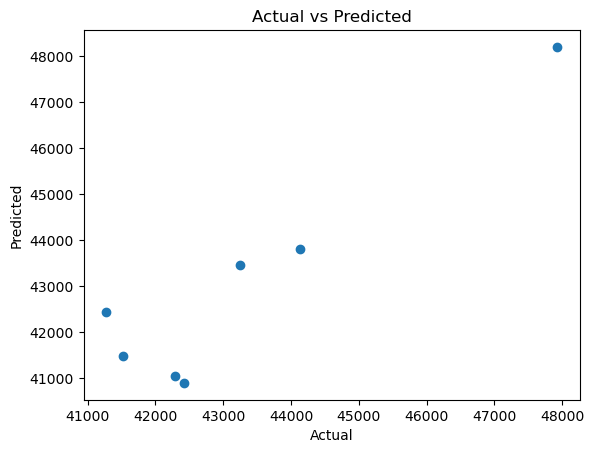

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()